In [58]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser

In [ ]:
# import os
# os.environ["HUGGINGFACEHUB_API_TOKEN"] = ""

In [60]:
llm = HuggingFaceEndpoint(
    repo_id = "deepseek-ai/DeepSeek-V3.2", #  Qwen/Qwen3-4B-Instruct-2507
    task = "text-generation",
    max_new_tokens=3000,
)
model = ChatHuggingFace(llm = llm)

In [61]:
from typing import List, Literal
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(...,description="One sentence describing what the reader should be able to do or understand after this section.")
    bullets: List[str] = Field(...,min_length=3,max_length=5,description="3–5 concrete, non-overlapping subpoints to cover in this section.")
    target_words: int = Field(...,ge=120,le=450,description="Target word count for this section.")

    section_type: Literal[
        "intro",
        "core",
        "examples",
        "checklist",
        "common_mistakes",
        "conclusion"
    ] = Field(...,description="Type of this blog section. Use common_mistakes exactly once.")


class Plan(BaseModel):
    blog_title: str
    audience: str = Field(...,description="Who this blog is written for.")
    tone: str = Field(..., description="Writing tone, such as practical, crisp, technical.")

    tasks: List[Task]

In [62]:
from langchain_core.output_parsers import JsonOutputParser

parser = JsonOutputParser()
planner_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are a senior technical writer and developer advocate.

Your job is to create a highly actionable outline for a technical blog.

HARD REQUIREMENTS:

1. Create 5–7 sections (tasks).

2. For EVERY task, provide ALL of these fields:
   - id
   - title
   - goal
   - bullets
   - target_words
   - section_type

3. Field requirements:

   - id:
     MUST be an integer such as 1, 2, 3, 4.

   - title:
     MUST be a clear string describing the section.

   - goal:
     MUST be exactly one sentence describing what the reader
     should understand or be able to do after this section.

   - bullets:
     MUST be an array containing 3–5 concrete,
     non-overlapping strings.

   - target_words:
     MUST be an integer between 120 and 450.

   - section_type:
     MUST be exactly one of:
       "intro"
       "core"
       "examples"
       "checklist"
       "common_mistakes"
       "conclusion"

4. Use "common_mistakes" EXACTLY ONCE.

5. The overall plan MUST contain:
   - blog_title
   - audience
   - tone
   - tasks

TECHNICAL QUALITY:

- Assume the reader is a developer.
- Use correct technical terminology.
- Prefer the following general structure:

  problem → intuition → core concepts → implementation
  → examples → trade-offs → common mistakes → conclusion

- Bullets must be concrete and actionable.
- Avoid vague bullets such as:
  "Explain X"
  "Discuss Y"
  "Talk about Z"

- Instead, describe exactly what should be:
  demonstrated, implemented, compared, tested, measured, or verified.

The plan should include relevant engineering considerations such as:

- minimal working examples or code
- edge cases and failure modes
- performance and cost
- debugging or observability
- security/privacy when relevant

ORDERING:

- Start with an introduction and problem framing.
- Explain core concepts before advanced concepts.
- Include practical examples where useful.
- Include implementation details where relevant.
- Include trade-offs where relevant.
- Include exactly one "common_mistakes" section.
- End with a conclusion, checklist, or practical next steps.

IMPORTANT OUTPUT RULES:

Return ONLY ONE valid JSON object.

The JSON object MUST contain exactly these top-level fields:

- blog_title
- audience
- tone
- tasks

The "tasks" field MUST contain 5–7 task objects.

EVERY task object MUST contain ALL SIX fields:

- id
- title
- goal
- bullets
- target_words
- section_type

Do NOT omit any field.

Do NOT use strings for "id".

For example, this is INVALID:

"id": "architecture_breakdown"

The id MUST be an integer:

"id": 1

The "bullets" field MUST be an array of 3–5 strings.

The "target_words" field MUST be an integer between 120 and 450.

The "section_type" field MUST be one of the six allowed values.

Use "common_mistakes" exactly once.

Before returning the JSON, internally verify that:

- there are 5–7 tasks
- every task has all six required fields
- every id is an integer
- every task has 3–5 bullets
- every target_words value is between 120 and 450
- every section_type is valid
- common_mistakes appears exactly once

Do not return explanations.
Do not return Markdown.
Do not return ```json fences.
Return only the JSON object.

{format_instructions}
"""
    ),
    (
        "human",
        "{topic}"
    )
])

planner_prompt = planner_prompt.partial(
    format_instructions=parser.get_format_instructions()
)

planner_chain = planner_prompt | model | parser

In [63]:
# TypedDict for the state of the blog writing process
class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add] # Each worker perform its task and add the result to the sections list
    final_blog: str

In [64]:
def orchestrator(state: State) -> dict:
    raw_plan = planner_chain.invoke({
        "topic": state["topic"]
    })

    print("\n========== RAW PLAN ==========")
    print(raw_plan)
    print("==============================\n")

    plan = Plan.model_validate(raw_plan)

    return {"plan": plan}

In [65]:
# After Orchestartor Node, we dont know how many sections are there, so we cannot determine no of workers so we create an intermediate
# node called fanout, it will simply check how many sections are there in Plan object and for each task it will trigger worker, it is done using 'Send'
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state['topic'], "plan": state['plan']}) 
            for task in state['plan'].tasks]

In [66]:
def worker(payload: dict) -> dict:
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    section_md = model.invoke(
        [
            SystemMessage(
                content=(
                    "You are a senior technical writer and developer advocate. "
                    "Write ONE section of a technical blog post in Markdown.\n\n"

                    "Hard constraints:\n"
                    "- Follow the provided Goal.\n"
                    "- Cover ALL Bullets in the given order.\n"
                    "- Do not skip or merge bullets.\n"
                    "- Stay close to the Target word count (±15%).\n"
                    "- Output ONLY the section content in Markdown.\n"
                    "- Do NOT include the blog title as an H1.\n"
                    "- Do NOT add extra commentary.\n\n"

                    "Technical quality:\n"
                    "- Be precise and implementation-oriented.\n"
                    "- Assume the reader is a developer.\n"
                    "- Prefer concrete technical details over generic explanations.\n"
                    "- Explain trade-offs when relevant.\n"
                    "- Mention edge cases or failure modes when relevant.\n"
                    "- If you mention a best practice, briefly explain why.\n\n"

                    "When appropriate, include at least one of:\n"
                    "- a small code snippet\n"
                    "- a tiny example input/output\n"
                    "- a practical checklist\n"
                    "- a simple architecture or flow description\n\n"

                    "Markdown style:\n"
                    "- Start with a ## section heading.\n"
                    "- Use short paragraphs.\n"
                    "- Use bullet lists where helpful.\n"
                    "- Use code fences for code.\n"
                    "- Avoid fluff and marketing language.\n"
                )
            ),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Topic: {topic}\n\n"

                    f"Section: {task.title}\n"
                    f"Section type: {task.section_type}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Bullets:{bullets_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [ ]:
import re
from pathlib import Path

def reducer(state: State) -> dict:
    title = state["plan"].blog_title

    # Combine all generated sections
    body = "\n\n".join(state["sections"]).strip()

    # Create final Markdown
    final_md = f"# {title}\n\n{body}\n"

    # Make a safe filename
    filename = re.sub(r'[<>:"/\\|?*]', '', title)
    filename = filename.strip().lower().replace(" ", "_") + ".md"

    # Save the blog
    output_path = Path(filename)
    output_path.write_text(final_md,encoding="utf-8")

    print(f"Blog saved to: {output_path.resolve()}")

    return {"final_blog": final_md}

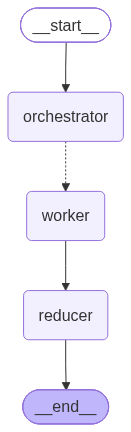

In [68]:
g = StateGraph(State)

g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestrator")

g.add_conditional_edges(
    "orchestrator",
    fanout,
    ["worker"]
)

g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

graph = g.compile()
graph

In [69]:
response = graph.invoke({"topic": "Write a blog on Transformer Architecture", "sections": []})


========== RAW PLAN ==========
{'blog_title': 'Understanding Transformer Architecture: From Attention to Implementation', 'audience': 'Developers with intermediate machine learning knowledge, familiar with neural networks and sequence processing', 'tone': 'Technical, clear, and practical with emphasis on understanding through implementation', 'tasks': [{'id': 1, 'title': 'The Sequence Modeling Problem and Why Transformers Matter', 'goal': 'Understand the limitations of previous sequence models (RNNs, LSTMs) and why transformers revolutionized natural language processing.', 'bullets': ['Demonstrate how RNNs suffer from vanishing gradients in long sequences', 'Show the computational bottleneck of sequential processing in RNNs/LSTMs', 'Illustrate the parallelization advantage of transformers with a simple diagram concept', 'Present real-world performance metrics comparing transformers vs LSTMs on translation tasks'], 'target_words': 180, 'section_type': 'intro'}, {'id': 2, 'title': 'Core